# Pengembangan *physics informed neural networks* (PINNs) untuk penyelesaian PDP

# 1. Import *Library* dan *Package* yang diperlukan.

Kode dapat dijalankan dengan TensorFlow versi `2.5.x`.
Implementasi model dilakukan dengan *library* [NumPy](https://numpy.org/doc/stable/user/whatisnumpy.html) dan *library* untuk *machine learning* [TensorFlow](https://www.tensorflow.org/).

Telah dikembangkan implementasi *class* untuk pembuatan PINN sebagai objek dari Keras pada sebuah *package* yang disimpan dalam *file* `PINNPDESolver.py`.

Komputasi dilakukan pada Google Colab.

In [1]:
print_plot = True

from google.colab import drive
drive.mount('/content/drive')
# Current Working Directory
dir = '/content/drive/My Drive/Tugas Akhir/Colab'

import sys
sys.path.insert(0, dir)

# Import TensorFlow and NumPy
import tensorflow as tf
import numpy as np

# Import Physics-Informed Neural Network
import PINNPDESolver as pinn

# Import Combined Learning Rate Decay
from CombinedDecay import CombinedDecay

# Import time
from time import time

# Import matplotlib for plots
import matplotlib.pyplot as plt

# Creating tables
import pandas as pd
from tabulate import tabulate

Mounted at /content/drive


In [3]:
if print_plot is True:
  !sudo apt install cm-super dvipng texlive-latex-extra texlive-latex-recommended

  pgf_with_latex = {                      # setup matplotlib to use latex for output
      "pgf.texsystem": "pdflatex",        # change this if using xetex or lautex
      "text.usetex": True,                # use LaTeX to write all text
      "font.family": "serif",
      "font.serif": [],                   # blank entries should cause plots to inherit fonts from the document
      "font.sans-serif": [],
      "font.monospace": [],
      "axes.labelsize": 24,               # LaTeX default is 10pt font.
      "font.size": 24,
      "legend.fontsize": 24,               # Make the legend/label fonts a little smaller
      "xtick.labelsize": 22,
      "ytick.labelsize": 22,
      # "pgf.preamble": [
      #     r"\usepackage[utf8x]{inputenc}",    # use utf8 fonts becasue your computer can handle it :)
      #     r"\usepackage[T1]{fontenc}",        # plots will be generated using this preamble
      #     ]
      }
  plt.rcParams.update(pgf_with_latex)

Reading package lists... Done
Building dependency tree       
Reading state information... Done
cm-super is already the newest version (0.3.4-15).
dvipng is already the newest version (1.15-1.1).
texlive-latex-extra is already the newest version (2019.202000218-1).
texlive-latex-recommended is already the newest version (2019.20200218-1).
0 upgraded, 0 newly installed, 0 to remove and 23 not upgraded.


In [4]:
# Set data type
DTYPE='float32'
tf.keras.backend.set_floatx(DTYPE)

# Set constants
pi = tf.constant(np.pi, dtype=DTYPE)

# 2. Persamaan Korteweg-de Vries (KdV) 2-Soliton dan Transformasi menjadi *Loss Function*

Persamaan KdV yang akan digunakan adalah

$$
\begin{equation}
    u_t + 6uu_{x} + u_{xxx} = 0, \quad -\infty<x<\infty, \quad t>0
\end{equation}.
$$
Diberikan *initial condition* (IC)
$$
\begin{equation}
    u(x,\,0) = -N(N+1)sech^2(x).
\end{equation}
$$
<!-- Solusi unik masalah ini adalah
$$
\begin{equation}
	        u(x,\;t) = -2sech^2(x-4t).
\end{equation}
$$ -->

In [5]:
a = [1, 0.5]
lambda_star = [6, 1]

# Define initial condition
import math
def fun_u_0(x):
    return 2 * (4 * (a[0] - a[1]) ** 2 / (a[0] + a[1]) ** 2 * a[0] ** 2 * tf.exp(2 * x * a[0]) * tf.exp(2 * x * a[1]) + 8 * (a[0] - a[1]) ** 2 / (a[0] + a[1]) ** 2 * a[0] * tf.exp(2 * x * a[0]) * a[1] * tf.exp(2 * x * a[1]) + 4 * (a[0] - a[1]) ** 2 / (a[0] + a[1]) ** 2 * tf.exp(2 * x * a[0]) * a[1] ** 2 * tf.exp(2 * x * a[1]) + 4 * a[0] ** 2 * tf.exp(2 * x * a[0]) + 4 * a[1] ** 2 * tf.exp(2 * x * a[1])) / ((a[0] - a[1]) ** 2 / (a[0] + a[1]) ** 2 * tf.exp(2 * x * a[0]) * tf.exp(2 * x * a[1]) + tf.exp(2 * x * a[0]) + tf.exp(2 * x * a[1]) + 1) - 2 * (2 * (a[0] - a[1]) ** 2 / (a[0] + a[1]) ** 2 * a[0] * tf.exp(2 * x * a[0]) * tf.exp(2 * x * a[1]) + 2 * (a[0] - a[1]) ** 2 / (a[0] + a[1]) ** 2 * tf.exp(2 * x * a[0]) * a[1] * tf.exp(2 * x * a[1]) + 2 * a[0] * tf.exp(2 * x * a[0]) + 2 * a[1] * tf.exp(2 * x * a[1])) ** 2 / ((a[0] - a[1]) ** 2 / (a[0] + a[1]) ** 2 * tf.exp(2 * x * a[0]) * tf.exp(2 * x * a[1]) + tf.exp(2 * x * a[0]) + tf.exp(2 * x * a[1]) + 1) ** 2

# Define residual of the PDE
def fun_r(t, x, u, u_t, u_x, u_xx, u_xxx, lambd = lambda_star):
    return u_t + lambd[0] * u * u_x + lambd[1] * u_xxx

In [6]:
# Solusi Eksplisit
def u_expl(t, x):
    """Solusi eksplisit persamaan KdV."""
    return 2 * (4 * (a[0] - a[1]) ** 2 / (a[0] + a[1]) ** 2 * a[0] ** 2 * math.exp(-8 * t * a[0] ** 3 + 2 * x * a[0]) * math.exp(-8 * t * a[1] ** 3 + 2 * x * a[1]) + 8 * (a[0] - a[1]) ** 2 / (a[0] + a[1]) ** 2 * a[0] * math.exp(-8 * t * a[0] ** 3 + 2 * x * a[0]) * a[1] * math.exp(-8 * t * a[1] ** 3 + 2 * x * a[1]) + 4 * (a[0] - a[1]) ** 2 / (a[0] + a[1]) ** 2 * math.exp(-8 * t * a[0] ** 3 + 2 * x * a[0]) * a[1] ** 2 * math.exp(-8 * t * a[1] ** 3 + 2 * x * a[1]) + 4 * a[0] ** 2 * math.exp(-8 * t * a[0] ** 3 + 2 * x * a[0]) + 4 * a[1] ** 2 * math.exp(-8 * t * a[1] ** 3 + 2 * x * a[1])) / ((a[0] - a[1]) ** 2 / (a[0] + a[1]) ** 2 * math.exp(-8 * t * a[0] ** 3 + 2 * x * a[0]) * math.exp(-8 * t * a[1] ** 3 + 2 * x * a[1]) + math.exp(-8 * t * a[0] ** 3 + 2 * x * a[0]) + math.exp(-8 * t * a[1] ** 3 + 2 * x * a[1]) + 1) - 2 * (2 * (a[0] - a[1]) ** 2 / (a[0] + a[1]) ** 2 * a[0] * math.exp(-8 * t * a[0] ** 3 + 2 * x * a[0]) * math.exp(-8 * t * a[1] ** 3 + 2 * x * a[1]) + 2 * (a[0] - a[1]) ** 2 / (a[0] + a[1]) ** 2 * math.exp(-8 * t * a[0] ** 3 + 2 * x * a[0]) * a[1] * math.exp(-8 * t * a[1] ** 3 + 2 * x * a[1]) + 2 * a[0] * math.exp(-8 * t * a[0] ** 3 + 2 * x * a[0]) + 2 * a[1] * math.exp(-8 * t * a[1] ** 3 + 2 * x * a[1])) ** 2 / ((a[0] - a[1]) ** 2 / (a[0] + a[1]) ** 2 * math.exp(-8 * t * a[0] ** 3 + 2 * x * a[0]) * math.exp(-8 * t * a[1] ** 3 + 2 * x * a[1]) + math.exp(-8 * t * a[0] ** 3 + 2 * x * a[0]) + math.exp(-8 * t * a[1] ** 3 + 2 * x * a[1]) + 1) ** 2

In [7]:
# Set boundary
tmin = -3.
tmax = 3.
xmin = -15.
xmax = 15.

# Lower bounds
lb = tf.constant([tmin, xmin], dtype=DTYPE)
# Upper bounds
ub = tf.constant([tmax, xmax], dtype=DTYPE)

# Persiapan Pemodelan

### Pembangkitan Data *Training* dan *Collocation Points*

Penentuan Jumlah Data

In [8]:
# Set number of data points
N_0 = 50000+50000
N_r = 10000

Pembangkitan Data

In [9]:
plot = True

# Set random seed for reproducible results
tf.random.set_seed(0)

if plot == True:
  # Draw uniform sample points for initial boundary data -> titik di batas domain, definisi domain adalah bidang (x,t)
  t_0 = tf.zeros((N_0,1), dtype=DTYPE)
  # t_0 = tf.ones((N_0,1), dtype=DTYPE)*lb[0]

  x_0 = tf.random.uniform((N_0,1), lb[1], ub[1], dtype=DTYPE)

  # x_0 = tf.concat([x_0, tf.random.uniform((int(N_0/2),1), -10, 10, dtype=DTYPE)], axis=0)

  # x_0 = tf.random.uniform((int(N_0/10),1), lb[1], ub[1], dtype=DTYPE)
  # x_0 = tf.concat([x_0, tf.random.uniform((int(9*N_0/10),1), -10, 10, dtype=DTYPE)], axis=0)
  X_0 = tf.concat([t_0, x_0], axis=1)

  # Evaluate initial condition at x_0
  u_0 = fun_u_0(x_0)
  # u_0 = fun_u_0(tf.where(tf.math.greater(x_0, tf.constant(10, dtype=DTYPE)), tf.math.negative(x_0), x_0))
  # u_0 = tf.where(tf.math.is_nan(u_0), tf.zeros_like(u_0), u_0)

  # Collect boundary and inital data in lists
  X_data = [X_0]
  u_data = [u_0]

  # Draw uniformly sampled collocation points -> titik interior domain
  t_r = tf.random.uniform((N_r,1), lb[0], ub[0], dtype=DTYPE)
  x_r = tf.random.uniform((N_r,1), lb[1], ub[1], dtype=DTYPE)
  X_r = tf.concat([t_r, x_r], axis=1)

elif plot == False:
  X_data, u_data, fig = pinn.generate_training_data(N_0, N_0, fun_u_0, fun_u_0, lb, ub)
  X_r = pinn.generate_collocation_points(N_r, lb, ub)

# fun_u_0(tf.constant(15, dtype=DTYPE))
# np.array(tf.math.is_nan(u_0)).sum()

Next, we illustrate the collocation points (red circles) and the positions where the boundary and initial conditions will be enforced (cross marks, color indicates value).

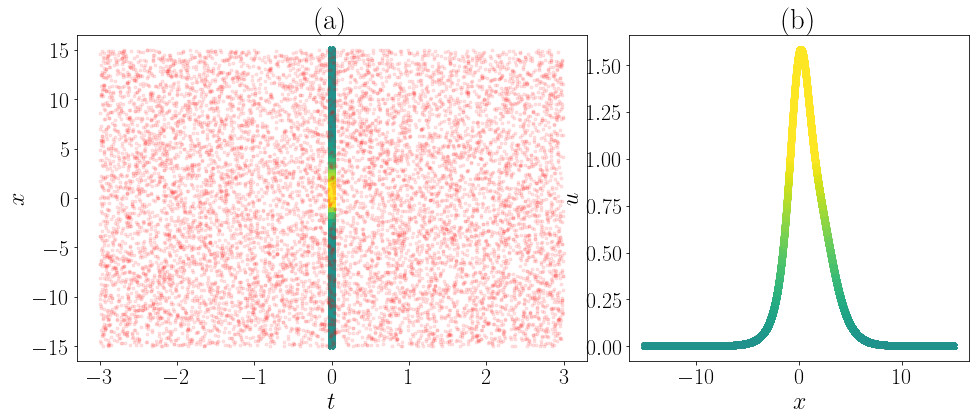

In [10]:
if plot == True:
  fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(16, 6),
                                 gridspec_kw={
                                     'width_ratios': [9, 6],
                                     'wspace': 0.1})
  
  ax1.scatter(t_0, x_0, c=u_0, marker='X', vmin=-1, vmax=1)
  ax1.scatter(t_r, x_r, c='r', marker='.', alpha=0.1)
  ax1.set_xlabel('$t$')
  ax1.set_ylabel('$x$')
  ax1.set_title('(a)')

  ax2.scatter(x_0, u_0, c=u_0, marker='X', vmin=-1, vmax=1)
  ax2.set_xlabel('$x$')
  ax2.set_ylabel('$u$')
  # ax2.invert_yaxis()
  ax2.set_title('(b)')

  # plt.savefig('kdv_eqn_fwd_train.pdf', dpi=600, bbox_inches='tight', facecolor='none')
  plt.show()

### Persiapan Perhitungan *Loss Function*

In the following code cell, we define a function which evaluates the residual

$$
\begin{align}
    r_\theta (t,x) := \partial_t u_\theta (t,x) + \mathcal{N}[u_\theta] (t,x).
\end{align}
$$

of the nonlinear PDE in the points $X_r = \{(t^r_i,x^r_i)\}_{i=1}^{N_r}$.
To compute the necessary partial derivatives we use the automatic differentiation capabilities of TensorFlow.

For the kdv equation, this entails computing $\partial_t u_\theta$, $\partial_x u_\theta$ and $\partial_{xx} u_\theta$.
In TensorFlow, this is done via a `GradientTape`, see also the [documentation](https://www.tensorflow.org/api_docs/python/tf/GradientTape), which keeps track of the `watched` variables, in our case `t` and `x`, in order to compute the derivatives.

In [11]:
def get_r(t, x, model, fun_r):
    
    # A tf.GradientTape is used to compute derivatives in TensorFlow
    with tf.GradientTape(persistent=True) as tape1:  
        
        tape1.watch(x)        
        with tf.GradientTape(persistent=True) as tape2:
          
          tape2.watch(x)
          with tf.GradientTape(persistent=True) as tape3:
          
            # Variables t and x are watched during tape
            # to compute derivatives u_t and u_x
            tape3.watch(t)
            tape3.watch(x)
          
            # Determine residual 
            u = model(tf.stack([t[:,0], x[:,0]], axis=1))

          # Compute gradient u_x and u_t
          u_t = tape3.gradient(u, t)
          u_x = tape3.gradient(u, x)       
        
        u_xx = tape2.gradient(u_x, x)
    
    u_xxx = tape1.gradient(u_xx, x)

    del tape1
    del tape2
    del tape3

    return fun_r(t, x, u, u_t, u_x, u_xx, u_xxx)


# # Alternative with tf.gradients
# def fwd_gradients(U, x):
#   return tf.gradients(U, x)[0]

# @tf.function  
# def get_r(t, x, model, fun_r):
#   u = model(tf.stack([t[:,0], x[:,0]], axis=1))
#   u_t = fwd_gradients(u, t)
#   u_x = fwd_gradients(u, x)
#   u_xx = fwd_gradients(u_x, x)
#   u_xxx = fwd_gradients(u_xx, x)

#   return fun_r(t, x, u, u_t, u_x, u_xx, u_xxx)

### Persiapan Arsitektur PINN

In this example, adopted from 
([Raissi et al., 2017 (Part I)](https://arxiv.org/abs/1711.10561)), we assume a feedforward neural network of the following structure:
- the input is scaled elementwise to lie in the interval $[-1,1]$,
- followed by 8 fully connected layers each containing 20 neurons and each followed by a hyperbolic tangent activation function,
- one fully connected output layer.

Pada *hidden layer* pertama, terdapat $2 \times 20 = 40$ parameter bobot dan $20$ parameter bias. Pada 9 *hidden layer* selanjutnya, terdapat $20 \times 20 = 400$ parameter bobot dan $20$ parameter bias dalam setiap *layer*. Di *output layer* yang terhubung *hidden layer* terakhir, terdapat $1 \times 20 = 20$ parameter bobot dan $20$ parameter bias. 

Maka, terdapat sejumlah
    \begin{align*}
        1 \times (40+20) + 9 \times (400+20) + 1 \times (20+20) = 3880
    \end{align*}
    parameter yang dapat ditentukan dan diperbarui pada setiap *epoch* dalam PINN.

In [12]:
# Initialize model aka u_\theta
arch = {'output_dim':1, 'num_hidden_layers':10, 'num_neurons_per_layer':20, 'activation':'tanh'}
n_models = 5

In [13]:
# Set up model architecture & 
# initialize weights to be copied to other models

models = [None] * n_models

for i in range(n_models):
  tf.random.set_seed(i)
  models[i] = pinn.PINN_NeuralNet(lb=lb, ub=ub, **arch)
  models[i].build((None, 2))

## 2. Persiapan *Optimizer*

In [14]:
# Preparing learning rates
lr_exp = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=450,
    decay_rate=0.9)

lr_pw = tf.keras.optimizers.schedules.PiecewiseConstantDecay([10000,20000],[1e-3,1e-4,5e-5])

lr_comb = CombinedDecay(boundaries=[1000,3000],
                        initial_learning_rate=1e-3,
                        decay_steps=450,
                        decay_rate=0.9,
                        values_steps=[4,20])

lr_comb.get_config()

{'initial_learning_rate': 0.001,
 'decay_steps': 450,
 'decay_rate': 0.9,
 'staircase': False,
 'boundaries': [1000, 3000],
 'values': [0.000791255401315759,
  0.00019781385032893975,
  9.890692516446987e-06],
 'values_steps': [4, 20],
 'name': None}

# Pemodelan

### Model

In [ ]:
mod=pinn.PINN_NeuralNet(lb, ub, **arch)
mod.build(input_shape=(None,2))
mod.set_weights(models[0].get_weights())

solver = pinn.PINN_PDESolver(mod, X_r, fun_r, get_r)
t0 = time()

# L-BFGS
solver.solve_with_ScipyOptimizer(X_data, u_data,min_loss=1e-5,
                            method='L-BFGS-B',
                            options={'maxiter': 50000,
                                     'maxfun': 50000,
                                     'maxcor': 50,
                                     'maxls': 50,
                                     'ftol': 1.0*np.finfo(float).eps})

# Adam
# optim = tf.keras.optimizers.Adam(learning_rate=lr_pw)
# solver.solve_with_TFoptimizer(optim, X_data, u_data, min_loss=1e-5)

print('\nComputation time: {} seconds'.format(time()-t0))

It 00000: l_u = 1.62716227e-01 l_f = 7.13330868e-04 loss = 1.63429558e-01
It 00050: l_u = 7.06288498e-03 l_f = 5.12712542e-03 loss = 1.21900104e-02
It 00100: l_u = 3.82462051e-03 l_f = 4.51332796e-03 loss = 8.33794847e-03
It 00150: l_u = 1.47235603e-03 l_f = 3.26431380e-03 loss = 4.73666983e-03
It 00200: l_u = 3.44077940e-04 l_f = 1.80057867e-03 loss = 2.14465661e-03
It 00250: l_u = 1.54384645e-04 l_f = 9.33832373e-04 loss = 1.08821702e-03
It 00300: l_u = 6.95994240e-05 l_f = 5.60551591e-04 loss = 6.30151015e-04
It 00350: l_u = 2.98306695e-05 l_f = 3.68012843e-04 loss = 3.97843512e-04
It 00400: l_u = 1.25983497e-05 l_f = 2.76632753e-04 loss = 2.89231102e-04
It 00450: l_u = 7.46019941e-06 l_f = 1.93086846e-04 loss = 2.00547045e-04
It 00500: l_u = 8.48778291e-06 l_f = 1.39401673e-04 loss = 1.47889456e-04
It 00550: l_u = 4.51505184e-06 l_f = 1.06252315e-04 loss = 1.10767367e-04
It 00600: l_u = 4.78509901e-06 l_f = 8.69221476e-05 loss = 9.17072466e-05
It 00650: l_u = 3.56414239e-06 l_f = 6

<AxesSubplot:xlabel='$n_{epoch}$', ylabel='$\\phi^{n_{epoch}}$'>

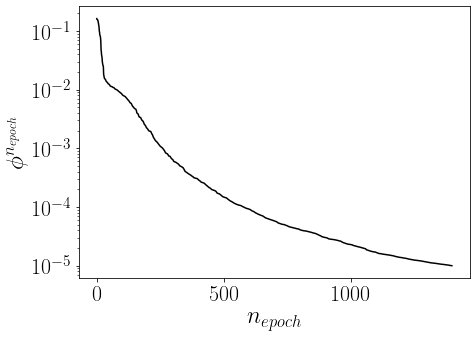

In [ ]:
solver.plot_loss_history()

### *Export* Model

*Export* bobot dan bias yang diperoleh pada *training*. *Export* riwayat *loss* pada *training* dalam bentuk `hist`.

In [ ]:
path = dir + "/model weights/kdv_2sol"
mod.save_weights(path+"/mod.h5", 'h5')
np.savetxt(path+"/loss.txt", solver.hist)

### *Import* Model
*Import* model beserta *loss* dari 5 percobaan pemodelan yang telah dilakukan. Langkah ini diperlukan jika penggunaan model di luar *training runtime*.

In [15]:
# timeout = 100
path = dir + "/model weights/kdv_2sol"

arch = {'output_dim':1, 'num_hidden_layers':10, 'num_neurons_per_layer':20, 'activation':'tanh'}

mod = pinn.PINN_NeuralNet(lb, ub, **arch)
mod.build(input_shape=(None,2))
mod.load_weights(path+"/mod.h5")
hist = np.loadtxt(path+"/loss.txt")

solver = pinn.PINN_PDESolver(mod, X_r, fun_r, get_r)

## Prediksi Solusi dan Evaluasi Kinerja Model

In [16]:
Nt = 1000; Nx = 1000
tspace = np.linspace(lb[0], ub[0], Nt + 1)
xspace = np.linspace(lb[1], ub[1], Nx + 1)
T, X = np.meshgrid(tspace, xspace)

### Solusi Eksplisit

In [17]:
path = dir + "/Data/"

# #Solusi Eksplisit
# u_star = np.empty([len(xspace), len(tspace)])
# i = 0
# for x_i in xspace:
#   j = 0
#   for t_i in tspace:    
#     u_star[i][j] = u_expl(t_i, x_i); j += 1
#   i += 1

# np.savetxt(path + "u_star_kdv_2soliton.csv", u_star)

u_star = np.loadtxt(path + "u_star_kdv_2soliton.csv")

Text(0.5, 0, '$u_(t,x)$')

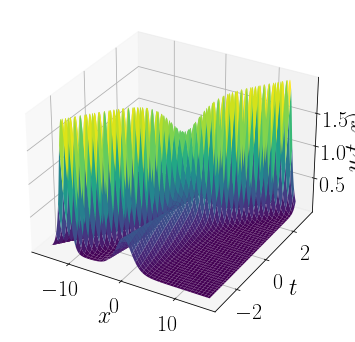

In [18]:
# Surface plot of solution u(t,x)
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, T, u_star, cmap='viridis');
# ax.view_init(35,35)
ax.set_xlabel('$x$')
ax.set_ylabel('$t$')
ax.set_zlabel('$u_(t,x)$')
# ax.set_title('Solusi analitik untuk persamaan panas.');
#plt.savefig('Burgers_Solution.pdf', bbox_inches='tight', dpi=300);

Text(0, 0.5, '$x$')

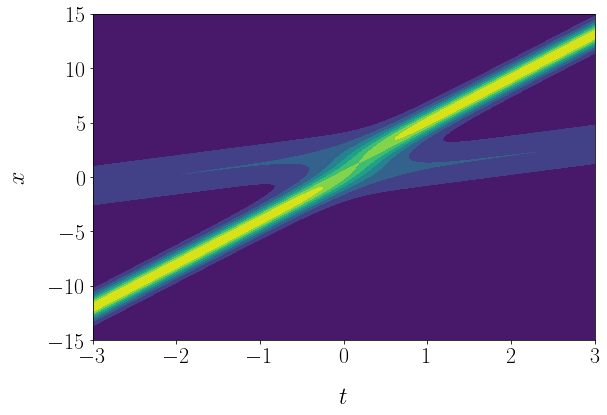

In [19]:
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111)
ax.contourf(T, X, u_star, cmap='viridis');
ax.set_xlabel('$t$', labelpad=20)
ax.set_ylabel('$x$', labelpad=20)

### Solusi Model

<Axes3D: xlabel='$x$', ylabel='$t$', zlabel='$u_\\theta(t,x)$'>

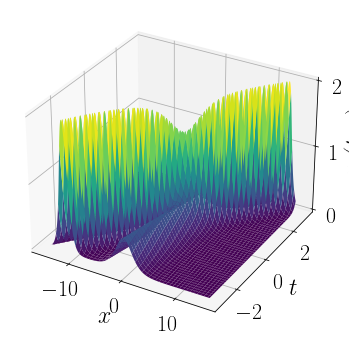

In [20]:
u_PINN = solver.predict_solution()
solver.plot_solution(u_PINN)

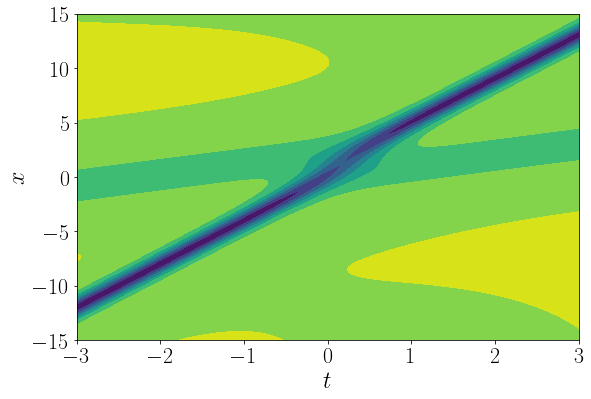

In [21]:
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111)
ax.contourf(T, X, -u_PINN, cmap='viridis');
# ax.contourf(T, X, u_PINN, cmap='plasma');
ax.set_xlabel('$t$')
ax.set_ylabel('$x$')

plt.savefig('kdv_2soliton_contour.pdf', dpi=600, bbox_inches='tight', facecolor='none')
plt.show()

In [22]:
def tau(t):
  return int((Nt*(t - lb[0])/(ub[0] - lb[0])).numpy())

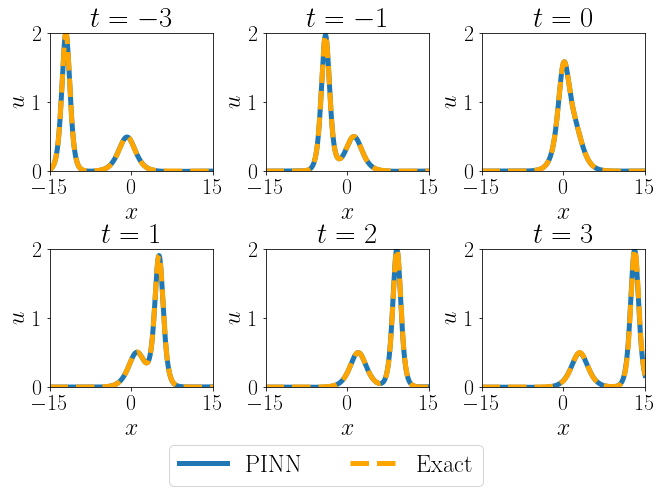

In [23]:
fig, ([ax1, ax2, ax3], [ax4, ax5, ax6]) = plt.subplots(nrows=2, ncols=3, figsize=(9, 6))

time_steps = [-3, -1, 0, 1, 2, 3]

for ax, t in zip([ax1, ax2, ax3, ax4, ax5, ax6], time_steps):
  ax.plot(xspace,u_PINN[:,tau(t)], lw=5)
  ax.plot(xspace,u_star[:,tau(t)], ls="--", lw=5, c='orange')
  ax.set_title('$t={}$'.format(t))
  ax.set_xlabel('$x$')
  ax.set_ylabel('$u$')
  ax.set_xlim([-15,15])
  ax.set_xticks(np.arange(-15, 15+1, 15))
  ax.set_ylim([0,2])

plt.tight_layout(pad=0)
plt.legend(['PINN', 'Exact'], 
           loc='lower center', bbox_to_anchor=(-0.95, -0.8), ncol=2, frameon=True)

plt.savefig('kdv_2soliton_plots.pdf', dpi=600, bbox_inches='tight', facecolor='none')
plt.show()

### Evaluasi Kinerja Model

Prediksi solusi dengan model-model yang telah dibuat.

In [24]:
pinn.evaluate_solution(u_PINN, u_star)

0.9317185368126394

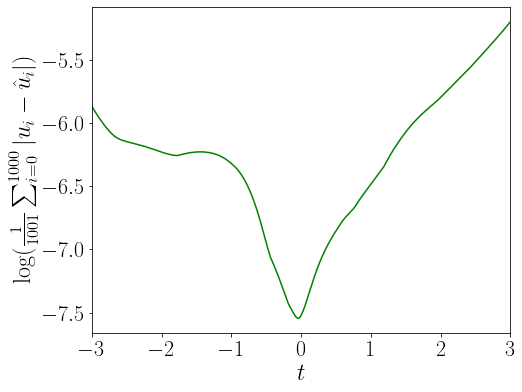

In [25]:
plt.figure(figsize=(7.5, 6))
# f = np.full((len(tspace),),-5.0)

error = pinn.evaluate_solution_log_time(u_PINN, u_star)
plt.plot(tspace, error, c='green')
# plt.plot(tspace, f, '--', c='black')

# idx = np.argwhere(np.diff(np.sign(f - error))).flatten()
# plt.plot(tspace[idx], f[idx], 'ro')

plt.xlabel('$t$')
plt.ylabel('$\log(\\frac{1}{1001}\sum_{i=0}^{1000}{|u_i-\hat{u}_i|})$')
plt.xlim([-3.0,3.0])
plt.xticks(np.arange(-3, 3+1, 1))
# plt.ylim([-9.00,-7.00])

plt.savefig('kdv_2soliton_error.pdf', dpi=600, bbox_inches='tight', facecolor='none')

plt.show()

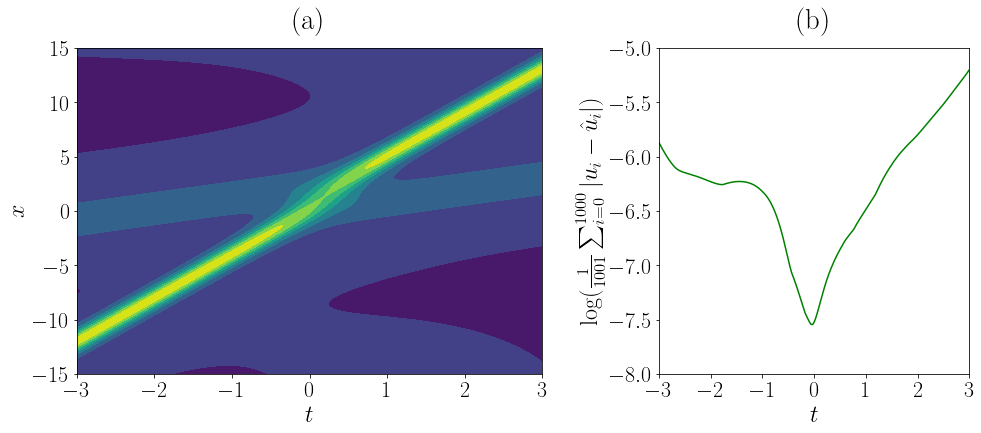

In [26]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(16, 6),
                                gridspec_kw={
                                    'width_ratios': [9, 6],
                                    'wspace': 0.3})

ax1.contourf(T, X, u_PINN, cmap='viridis');
ax1.set_xlabel('$t$')
ax1.set_ylabel('$x$')
ax1.set_title('(a)', pad=20)

ax2.plot(tspace, error, c='green')
ax2.set_xlabel('$t$')
ax2.set_ylabel('$\log(\\frac{1}{1001}\sum_{i=0}^{1000}{|u_i-\hat{u}_i|})$')
ax2.set_xlim([-3.0,3.0])
ax2.set_xticks(np.arange(-3, 3+1, 1))
ax2.set_ylim([-8.0,-5.0])
ax2.set_title('(b)', pad=20)

plt.savefig('kdv_2soliton_contour_error.pdf', dpi=600, bbox_inches='tight', facecolor='none')
plt.show()

# Solusi Model Pada Domain Lebih Besar

In [ ]:
# Lower bounds
new_lb = tf.constant([-5, -20], dtype=DTYPE)
# Upper bounds
new_ub = tf.constant([5, 20], dtype=DTYPE)

# Set up meshgrid
tspace = np.linspace(new_lb[0], new_ub[0], Nt+1)
xspace = np.linspace(new_lb[1], new_ub[1], Nx+1)
T, X = np.meshgrid(tspace, xspace)
Xgrid = np.vstack([T.flatten(),X.flatten()]).T

new_u_star = np.empty([len(xspace), len(tspace)])
i = 0
for x_i in xspace:
  j = 0
  for t_i in tspace:    
    new_u_star[i][j] = u_expl(t_i, x_i); j += 1
  i += 1

In [ ]:
# Determine predictions of u(t, x)
upred = mod(tf.cast(Xgrid,DTYPE))
# Reshape upred
new_u_PINN = upred.numpy().reshape(Nt+1,Nx+1)

Text(0, 0.5, '$x$')

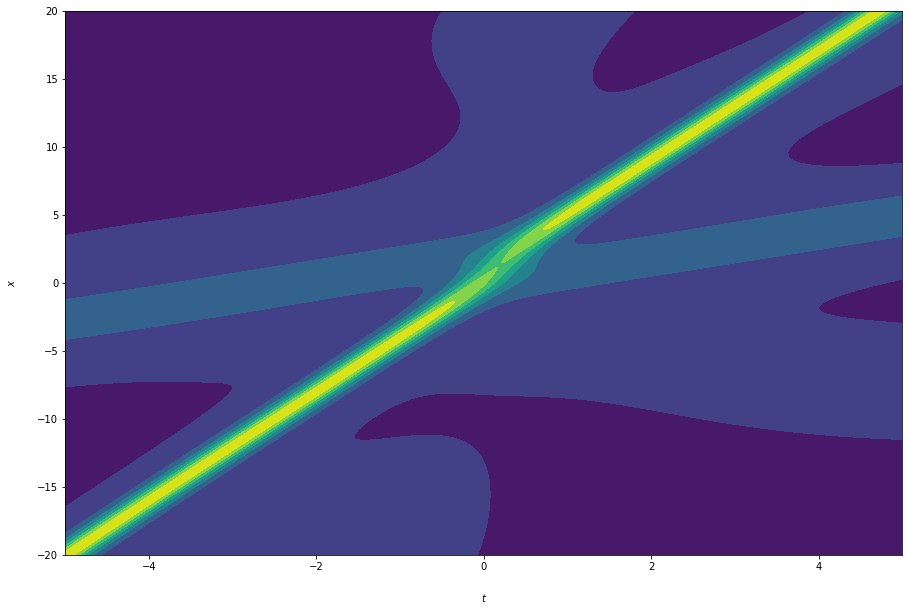

In [ ]:
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111)
ax.contourf(T, X, new_u_PINN, cmap='viridis');
ax.set_xlabel('$t$', labelpad=20)
ax.set_ylabel('$x$', labelpad=20)

In [ ]:
def new_tau(t):
  return int((Nt*(t - new_lb[0])/(new_ub[0] - new_lb[0])).numpy())

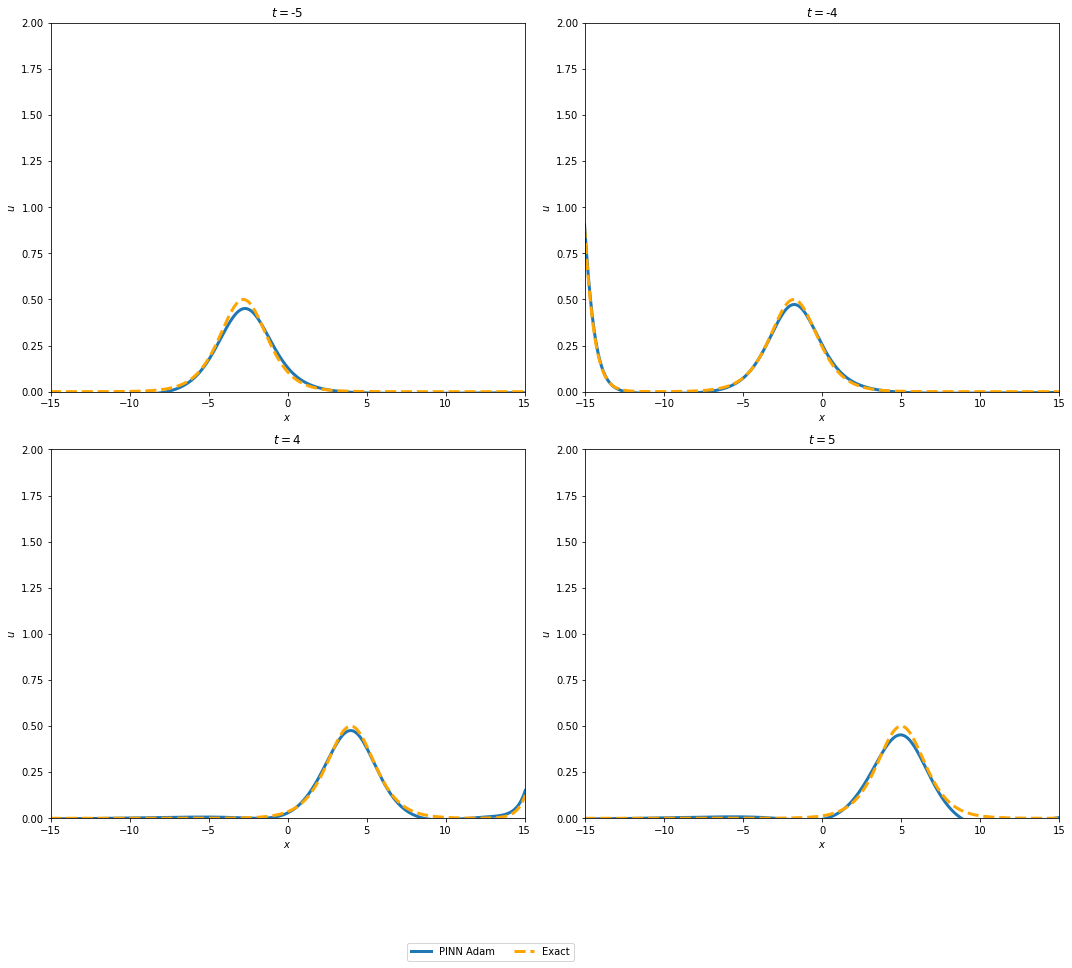

In [ ]:
fig, ([ax1, ax2], [ax3, ax4]) = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))

t1 = -5
ax1.plot(xspace,new_u_PINN[:,new_tau(t1)], lw=3)
ax1.plot(xspace,new_u_star[:,new_tau(t1)], ls="--", lw=3, c='orange')
ax1.set_xlabel('$x$')
ax1.set_ylabel('$u$')
ax1.set_title('$t=${}'.format(t1))
ax1.set_xlim([-15,15])
ax1.set_ylim([0,2])

t2 = -4
ax2.plot(xspace,new_u_PINN[:,new_tau(t2)], lw=3)
ax2.plot(xspace,new_u_star[:,new_tau(t2)], ls="--", lw=3, c='orange')
ax2.set_xlabel('$x$')
ax2.set_ylabel('$u$')
ax2.set_title('$t=${}'.format(t2))
ax2.set_xlim([-15,15])
ax2.set_ylim([0,2])

t3 = 4
ax3.plot(xspace,new_u_PINN[:,new_tau(t3)], lw=3)
ax3.plot(xspace,new_u_star[:,new_tau(t3)], ls="--", lw=3, c='orange')
ax3.set_xlabel('$x$')
ax3.set_ylabel('$u$')
ax3.set_title('$t=${}'.format(t3))
ax3.set_xlim([-15,15])
ax3.set_ylim([0,2])

t4 = 5
ax4.plot(xspace,new_u_PINN[:,new_tau(t4)], lw=3)
ax4.plot(xspace,new_u_star[:,new_tau(t4)], ls="--", lw=3, c='orange')
ax4.set_xlabel('$x$')
ax4.set_ylabel('$u$')
ax4.set_title('$t=${}'.format(t4))
ax4.set_xlim([-15,15])
ax4.set_ylim([0,2])

plt.tight_layout()
plt.legend(['PINN', 'Exact'], 
           loc='lower center', bbox_to_anchor=(-0.2, -0.4), ncol=3, frameon=True)

plt.show()

In [ ]:
pinn.evaluate_solution(new_u_PINN, new_u_star)

2.811407026883405